# CardioIA Fase 4 — Notebook 3: Ética e Governança (Ir Além 1)

Análise de **equidade (fairness)** do modelo de Transfer Learning por **gênero**, **faixa etária**
e **posição da incidência (AP/PA)**, sobre o conjunto de teste (split por paciente).

> ⚠️ **Protótipo acadêmico (FIAP).** Não é dispositivo médico, não foi validado clinicamente e não deve ser usado para diagnóstico real.

Métrica priorizada: **equalized odds / equal opportunity** (TPR e FPR por subgrupo), com
**intervalo de confiança (bootstrap)** — em diagnóstico médico, *demographic parity* é
inadequado porque a prevalência difere legitimamente por subgrupo. Requer o modelo treinado
(`transfer_mobilenetv2.keras`) e o `data_manifest.csv` anexados.


In [1]:
# ===== CardioIA Fase 4 - Grad-CAM + Fairness (Ir Alem 1) =====
# Carrega o modelo Transfer treinado, avalia equidade por subgrupo (fairness) e
# gera Grad-CAM (metodo manual, robusto a base aninhada). Saidas em /kaggle/working.
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

SEED = 565535
IMG = (224, 224)
OUT = Path("/kaggle/working")
np.random.seed(SEED); tf.random.set_seed(SEED)

INPUT = Path("/kaggle/input")
model_path = next(INPUT.rglob("transfer_mobilenetv2.keras"))
manifest_path = next(INPUT.rglob("data_manifest.csv"))
print("Modelo:", model_path); print("Manifesto:", manifest_path)

model = tf.keras.models.load_model(
    model_path, custom_objects={"preprocess_input": preprocess_input}, safe_mode=False)
mani = pd.read_csv(manifest_path)
test = mani[mani["split"] == "test"].copy().reset_index(drop=True)
paths = {p.name: str(p) for p in INPUT.rglob("*.png")}
test["fp"] = test["Image Index"].map(paths)
test = test.dropna(subset=["fp"]).reset_index(drop=True)
print("Imagens de teste:", len(test))

In [2]:
# ---------- 1) FAIRNESS (entregavel principal) ----------
def load(fp):
    return tf.cast(tf.image.resize(tf.io.decode_png(tf.io.read_file(fp), channels=3), IMG), tf.float32)

ds = tf.data.Dataset.from_tensor_slices(test["fp"].values).map(load).batch(32).prefetch(1)
test["score"] = model.predict(ds, verbose=0).ravel()
test["pred"] = (test["score"] >= 0.5).astype(int)

def rates(df):
    yt = df["target"].values.astype(int); yp = df["pred"].values.astype(int)
    P = int((yt == 1).sum()); Ng = int((yt == 0).sum())
    tp = int(((yp == 1) & (yt == 1)).sum()); fp = int(((yp == 1) & (yt == 0)).sum())
    tpr = tp / P if P else np.nan; fpr = fp / Ng if Ng else np.nan
    prec = tp / (tp + fp) if (tp + fp) else np.nan
    return tpr, fpr, prec, float((yp == yt).mean()), P, Ng

def boot(df, fn, B=1000):
    idx = np.arange(len(df)); vals = []
    for _ in range(B):
        v = fn(df.iloc[np.random.choice(idx, len(idx), replace=True)])
        if not np.isnan(v): vals.append(v)
    return (float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))) if vals else (np.nan, np.nan)

tpr_of = lambda d: (((d["pred"] == 1) & (d["target"] == 1)).sum() / max((d["target"] == 1).sum(), 1))
fpr_of = lambda d: (((d["pred"] == 1) & (d["target"] == 0)).sum() / max((d["target"] == 0).sum(), 1))

test["faixa_etaria"] = pd.cut(test["Patient Age"], [0, 45, 60, 120], labels=["<45", "45-60", ">60"], right=False)
rows = []
for attr in ["Patient Gender", "faixa_etaria", "View Position"]:
    for val, g in test.groupby(attr, observed=True):
        tpr, fpr, prec, acc, P, Ng = rates(g)
        tci = boot(g, tpr_of); fci = boot(g, fpr_of)
        rows.append({"atributo": attr, "subgrupo": str(val), "n": len(g), "positivos": P, "negativos": Ng,
                     "TPR": round(tpr, 3), "TPR_ic95": f"[{tci[0]:.2f},{tci[1]:.2f}]",
                     "FPR": round(fpr, 3), "FPR_ic95": f"[{fci[0]:.2f},{fci[1]:.2f}]",
                     "precisao": round(prec, 3), "acuracia": round(acc, 3)})
fair = pd.DataFrame(rows)
fair.to_csv(OUT / "fairness_metrics.csv", index=False)
print("\n==== FAIRNESS ====\n", fair.to_string(index=False))

gaps = {}
for attr in ["Patient Gender", "faixa_etaria", "View Position"]:
    s = fair[fair["atributo"] == attr]
    gaps[attr] = {"gap_TPR": round(float(s["TPR"].max() - s["TPR"].min()), 3),
                  "gap_FPR": round(float(s["FPR"].max() - s["FPR"].min()), 3)}
(OUT / "fairness_resumo.json").write_text(json.dumps({"gaps": gaps}, indent=2), encoding="utf-8")
print("\nGaps:", json.dumps(gaps))

for attr, slug in [("Patient Gender", "genero"), ("faixa_etaria", "idade")]:
    s = fair[fair["atributo"] == attr]; x = np.arange(len(s)); w = 0.35
    plt.figure(); plt.bar(x - w/2, s["TPR"], w, label="TPR"); plt.bar(x + w/2, s["FPR"], w, label="FPR")
    plt.xticks(x, s["subgrupo"]); plt.ylim(0, 1); plt.title(f"Equidade por {slug}"); plt.legend()
    plt.tight_layout(); plt.savefig(OUT / f"fairness_{slug}.png", dpi=130); plt.close()
print("Fairness OK.")

Modelo: /kaggle/input/datasets/diogozequini/cardioia-fase4-model/transfer_mobilenetv2.keras
Manifesto: /kaggle/input/datasets/diogozequini/cardioia-fase4-model/data_manifest.csv
Imagens de teste: 345

==== FAIRNESS ====
       atributo subgrupo   n  positivos  negativos   TPR    TPR_ic95   FPR    FPR_ic95  precisao  acuracia
Patient Gender        F 164         93         71 0.839 [0.76,0.91] 0.493 [0.38,0.61]     0.690     0.695
Patient Gender        M 181         83         98 0.699 [0.59,0.80] 0.316 [0.22,0.40]     0.652     0.691
  faixa_etaria      <45 134         73         61 0.712 [0.60,0.81] 0.295 [0.19,0.41]     0.743     0.709
  faixa_etaria    45-60 109         47         62 0.809 [0.68,0.91] 0.468 [0.35,0.60]     0.567     0.651
  faixa_etaria      >60 102         56         46 0.821 [0.72,0.91] 0.413 [0.27,0.55]     0.708     0.716
 View Position       AP 139         69         70 0.841 [0.75,0.92] 0.600 [0.49,0.71]     0.580     0.619
 View Position       PA 206        10

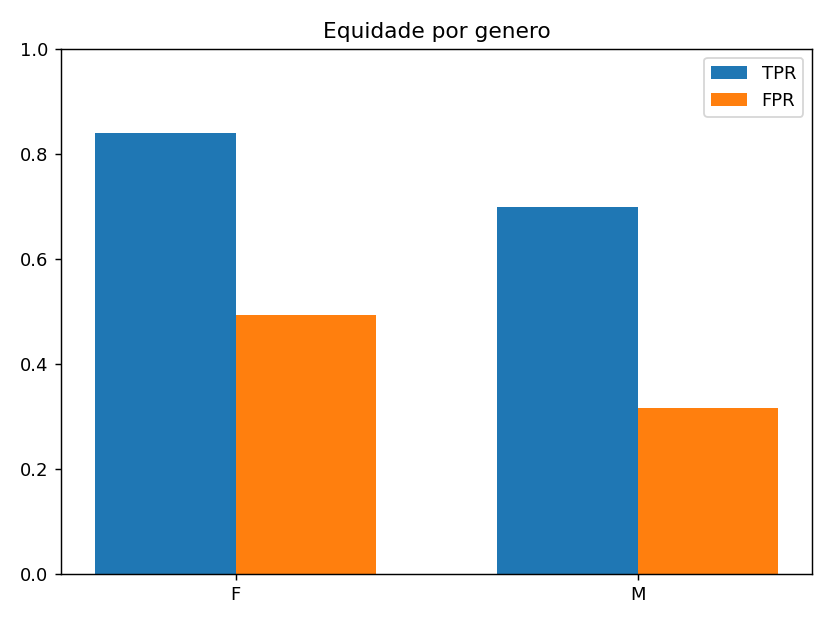

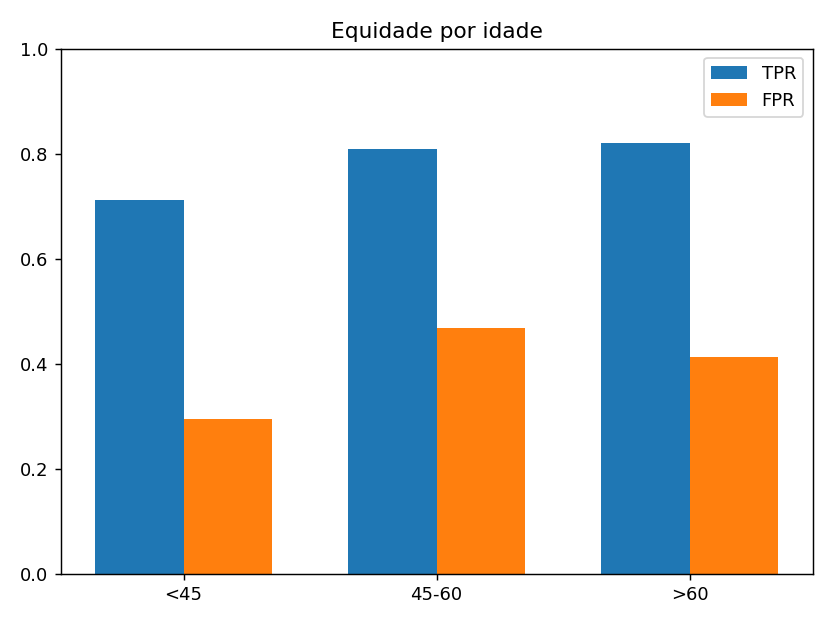

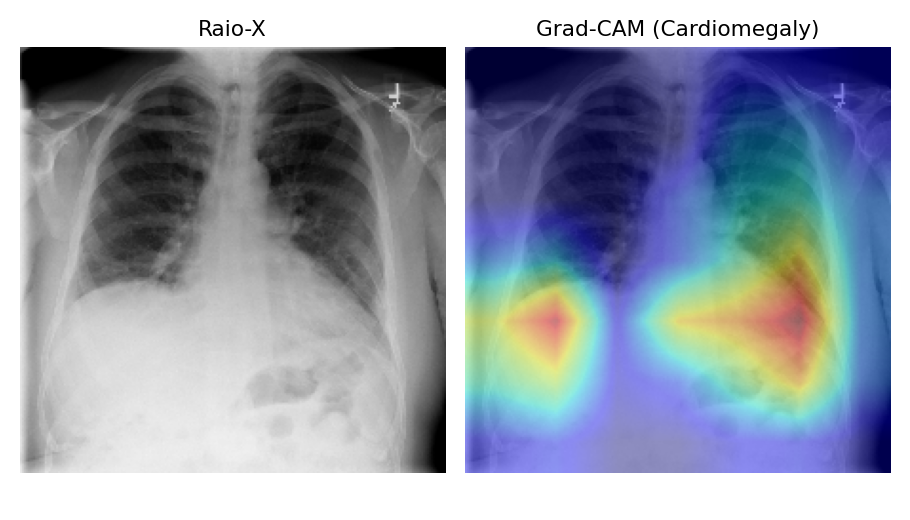

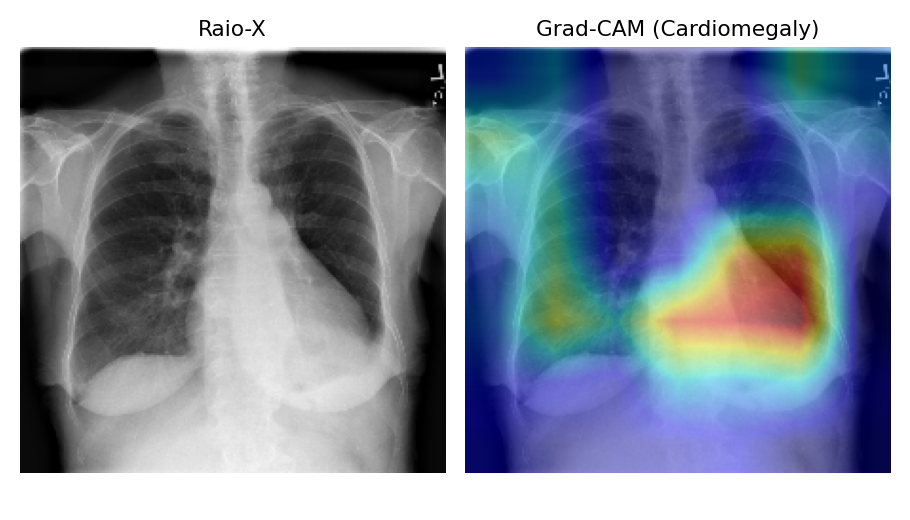

In [3]:
# ---------- 2) GRAD-CAM (metodo manual: chama a base no GradientTape) ----------
try:
    mnv2 = next(l for l in model.layers if hasattr(l, "layers") and "mobilenet" in l.name.lower())
    dense = model.get_layer("clf")
    print("Base:", mnv2.name)

    def gradcam(raw_batch):
        x = preprocess_input(tf.identity(raw_batch))
        with tf.GradientTape() as tape:
            conv = mnv2(x, training=False)
            tape.watch(conv)
            pooled = tf.reduce_mean(conv, axis=(1, 2))
            ch = dense(pooled)[:, 0]
        grads = tape.gradient(ch, conv)
        pg = tf.reduce_mean(grads, axis=(0, 1, 2))
        hm = tf.squeeze(conv[0] @ pg[..., None])
        return (tf.maximum(hm, 0) / (tf.reduce_max(hm) + 1e-8)).numpy()

    ex = test[test["target"] == 1].head(4).reset_index(drop=True)
    for i, row in ex.iterrows():
        raw = tf.image.resize(tf.io.decode_png(tf.io.read_file(row["fp"]), channels=3), IMG).numpy()
        hm = gradcam(raw[None].astype("float32"))
        hm_r = tf.image.resize(hm[..., None], IMG).numpy().squeeze()
        overlay = (0.4 * cm.jet(hm_r)[..., :3] * 255 + 0.6 * raw).astype("uint8")
        fig, ax = plt.subplots(1, 2, figsize=(7, 4))
        ax[0].imshow(raw.astype("uint8")); ax[0].set_title("Raio-X"); ax[0].axis("off")
        ax[1].imshow(overlay); ax[1].set_title("Grad-CAM (Cardiomegaly)"); ax[1].axis("off")
        plt.tight_layout(); plt.savefig(OUT / f"gradcam_{i+1}.png", dpi=130); plt.close()
    print("Grad-CAM OK (4 imagens).")
except Exception as e:
    print("Grad-CAM falhou (nao bloqueia):", repr(e))

print("FIM.")

## Resultados (execução real no Kaggle — teste, n=345)

| Atributo | Subgrupo | TPR | FPR | Precisão |
|---|---|---:|---:|---:|
| Gênero | F / M | 0.839 / 0.699 | 0.493 / 0.316 | 0.690 / 0.652 |
| Idade | <45 / 45-60 / >60 | 0.712 / 0.809 / 0.821 | 0.295 / 0.468 / 0.413 | 0.743 / 0.567 / 0.708 |
| Incidência | AP / PA | 0.841 / 0.729 | **0.600 / 0.242** | 0.580 / 0.765 |

Maior viés na **posição da incidência** (gap de FPR = 0.36): confirma o atalho técnico (AP ≈ pacientes
mais graves). Tabela com IC 95% em `fairness_metrics.csv`; discussão e mitigação em
`docs/relatorio_etica_fairness.md`.
